#Convolutional Neural Network

# Imports

In [ ]:
import zipfile
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Dropout, Activation, Conv2D, Flatten
from tensorflow.keras.layers import Input, BatchNormalization, MaxPooling2D

#Files Extraction

In [ ]:
tf.__version__

'2.20.0'

In [ ]:
zip_path = "Data.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_data:
  zip_data.extractall("/content/Data/")

In [ ]:
os.listdir("/content/Data/")

['training_set', 'test_set']

In [ ]:
train_path = "/content/Data/training_set/"
test_path = "/content/Data/test_set/"

train_images = os.listdir(train_path)
test_images = os.listdir(test_path)

print("train_images: ",len(train_images))
print("test_images: ",len(test_images))

train_images:  1
test_images:  1


In [ ]:
os.listdir(train_path) == ['cats', 'dogs']

False

In [ ]:
os.listdir(train_path)

['training_set']

In [ ]:
import os

train_set = [f for f in os.listdir(train_path) if not f.startswith('.')]

print(train_set)
print("Number of classes:", len(train_set))

['training_set']
Number of classes: 1


In [ ]:
os.listdir(test_path)

['test_set']

In [ ]:
test_set = [t for t in os.listdir(test_path) if not t.startswith(".")]

print(test_set)
print(f"Number of Classes {len(test_set)}")

['test_set']
Number of Classes 1


In [ ]:
train_set

['training_set']

In [ ]:
test_set

['test_set']

#Part 1
#Data Preprocessing
Preprocessing the Dataset

--> apply few transformations to images like

--------> Rrescaling, Zoom-in, Zoom-out, H-flip Etc...

So that Model Can Not Overfit with These Images

--> This is Called Image Augmentation

In [ ]:
data_gen = ImageDataGenerator(
                                rescale = 1./255,
                                shear_range = 0.2,
                                zoom_range = 0.2,
                                horizontal_flip = True
                              )

In [ ]:
import shutil

shutil.rmtree('/content/Data/training_set/.ipynb_checkpoints', ignore_errors=True)
shutil.rmtree('/content/Data/test_set/.ipynb_checkpoints', ignore_errors=True)

In [ ]:
# training_data = data_gen.flow_from_directory(
#                                               "/content/Data/training_set/",
#                                               target_size = (64, 64),
#                                               batch_size = 32,
#                                               class_mode = "binary"
#                                              )

In [ ]:
training_data = data_gen.flow_from_directory(
    "/content/Data/training_set/training_set/",
    target_size=(64,64),
    batch_size=32,
    class_mode="binary"
)

Found 8005 images belonging to 2 classes.


In [ ]:
training_data.classes

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [ ]:
training_data.class_indices

{'cats': 0, 'dogs': 1}

In [ ]:
len(training_data.classes)

8005

#Same We Have to with Testing_Data also

In [ ]:
data_gen_test = ImageDataGenerator(
    rescale = 1./255
    )

In [ ]:

testing_data = data_gen_test.flow_from_directory(
    "/content/Data/test_set/test_set",
    target_size=(64, 64),
    batch_size=32,
    class_mode="binary"
)

Found 2023 images belonging to 2 classes.


In [ ]:
testing_data.classes

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [ ]:
testing_data.class_indices

{'cats': 0, 'dogs': 1}

#Initializing CNN

Step 1 ---> Convolutional Layer

2D Convolutional Layer (Conv2D):

A Conv2D layer applies small filters (kernels) over an image to detect

features like:

edges

textures

patterns (eyes, ears in cats/dogs)

Filters

(also called kernels) are small matrices that scan over an image to detect specific features.

Filters are also Called as Feature Detectors So that These are used to Generate the new Type of images Like

Zoom in images

Zoom out image

Horizontal flip etc....

if we put Filters = 32 then 32 Features are Detected

Like One Filter Going to Get detect One Pattern and another filter Another Pattern Like those the 32 are going to get 32 different types of the Petterns

In early layers:

Filter 1 → vertical edges

Filter 2 → horizontal edges

Filter 3 → curves

Filter 4 → textures

In deeper layers:

Filter 10 → cat ear shape

Filter 15 → dog nose

Filter 25 → fur pattern

kernel_size

defines the size of the filter (matrix) used in convolution.

It tells how big the filter is that scans the image.

the Kernel Size means Feature Detector Size like for filters

Step 2

CNN Input Layer
Kerner_size = 3X3

CNN architecture
3 indicates that We are Going to work on the Colured Images

Step 3

Pooling Layer

pool_size = 2X2

Strides = 2 means the Jumping b/w the Matrixs in Input data



Step 4

Flatten Layer

Flatten Makes 2D --> 1D

Step 5

Full Connection

units = 128 No.of Nodes

Step 6

Output Layer

In [ ]:
cnn_model = Sequential()

# Model Input
cnn_model.add(
    Input(
        shape = (64, 64, 3)
  )
)

cnn_model.add(Conv2D(filters = 32, kernel_size = (3,3), activation = "relu"))
cnn_model.add(BatchNormalization())
# Pooling Layer
cnn_model.add(MaxPooling2D(pool_size = (2,2), strides = 2))


# Adding another Convolutionsl Layer
cnn_model.add(Conv2D(filters = 64, kernel_size = (3,3), activation = "relu"))
cnn_model.add(MaxPooling2D(pool_size = (2,2), strides = 2))


# Adding another Convolutionsl Layer
cnn_model.add(Conv2D(filters = 128, kernel_size = (3,3), activation = "relu"))
cnn_model.add(MaxPooling2D(pool_size = (2,2), strides = 2))

In [ ]:
cnn_model.layers

[<Conv2D name=conv2d, built=True>,
 <BatchNormalization name=batch_normalization, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Conv2D name=conv2d_2, built=True>,
 <MaxPooling2D name=max_pooling2d_2, built=True>]

In [ ]:
# Flatten Layer
cnn_model.add(Flatten())

cnn_model.add(Dense(units = 128, activation = 'relu'))
cnn_model.add(Dropout(0.5))

# Output Layer
cnn_model.add(Dense(units = 1, activation = "sigmoid"))

#Part 3

# Training the CNN

Compiling the CNN

In [ ]:
cnn_model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'] )

Training the CNN on Training set and evaluating on the test set

In [ ]:
# Epochs means How many times model Go through the whole data
cnn_model.fit(x = training_data, validation_data = testing_data, epochs = 25)

Epoch 1/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 98s 382ms/step - accuracy: 0.5919 - loss: 0.6649 - val_accuracy: 0.5279 - val_loss: 0.6817
Epoch 2/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 94s 374ms/step - accuracy: 0.6588 - loss: 0.6171 - val_accuracy: 0.6738 - val_loss: 0.5892
Epoch 3/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 93s 369ms/step - accuracy: 0.6791 - loss: 0.5936 - val_accuracy: 0.6520 - val_loss: 0.5949
Epoch 4/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 94s 376ms/step - accuracy: 0.7173 - loss: 0.5556 - val_accuracy: 0.7563 - val_loss: 0.5046
Epoch 5/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 94s 374ms/step - accuracy: 0.7288 - loss: 0.5305 - val_accuracy: 0.5507 - val_loss: 0.7059
Epoch 6/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 94s 374ms/step - accuracy: 0.7553 - loss: 0.5124 - val_accuracy: 0.6742 - val_loss: 0.5691
Epoch 7/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 94s 376ms/step - accuracy: 0.7689 - loss: 0.4808 - val_accuracy: 0.7598 - val_loss: 0.4860
Epoch 8/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 144s 386ms/step - accuracy: 0.7813 - loss: 

#Making a Single prediction

In [ ]:
import numpy as np
from keras.preprocessing import image

org_img = "/content/Data/test_set/test_set/dogs/dog.4020.jpg"

img = image.load_img(org_img, target_size=(64, 64))
test_img = image.img_to_array(img)
test_img = test_img / 255.0

test_img = np.expand_dims(test_img, axis = 0)


result = cnn_model.predict(test_img)
training_data.class_indices

if result[0][0] >= 0.5:
  Prediction = "Dog"
else:
  Prediction = "Cat"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


In [ ]:
print(Prediction)

Dog


In [ ]:
print(result)
print(result[0][0])

[[0.8558908]]
0.8558908


Text(0.5, 1.0, 'Predicted Category: Dog')

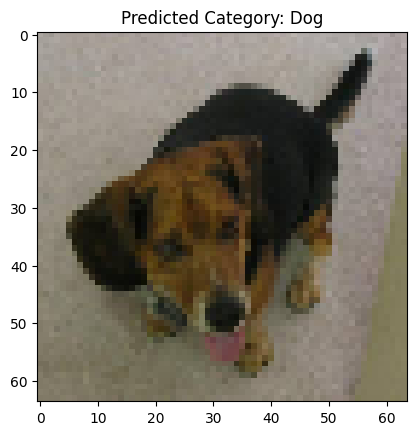

In [ ]:
plt.imshow(img)
plt.title(f"Predicted Category: {'Dog' if result[0][0] >= 0.5 else 'Cat'}")

In [ ]:
from keras.models import load_model

# Model Name
cnn_model.save("cnn_model.h5")

# Load the Saved Model
model = load_model("cnn_model.h5")